# Classification of the iFood 2019 dataset containing over 120k images in 251 classes
This part of the prohec
## Original Dataset
The Dataset was retrieved from the iFood 2019 dataset. \\
The number of training images is 118.475, the number of validation images is 11.994, test images are available but they do not have labels and therefore will not be used for this project.
## Reduced Dataset
Because of GPU limitations, the dataset is reduced to contain only a maximum of 150 images for class. \\
The number of training images in the final dataset is 37.534, this set is then split (80-20) in train and validation sets, for a total of 30.027 training images and 7.507 validation images. \\
The test images are constituted of the whole original validation set.
##Tasks to perform
1. Preprocessing: resizing, normalizing pixel values, etc.
2. Build a CNN architecture with a constraint of a number of parameters <5M
3. Implement both supervised and self-supervised approaches  
4. Evaluate the model using multiple metrics

## Prerequisites (libraries)

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import cv2
from PIL import Image
import requests
import tarfile
import time
import zipfile
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
%cd '/content/drive/MyDrive/Colab Notebooks/ProgettiEsami/ProjectSupervised'

/content/drive/MyDrive/Colab Notebooks/ProgettiEsami/ProjectSupervised


##Downloading and preprocessing of the data
The portion of the dataset used consists of: an annotation file of ~3 MB which contains a CSV with the annotation files mapping images to their label, a training file of ~2.5 GB containing the training images, which we will use to split as train and validation, and a validation file of ~230 MB containing the validation images that we will use for testing. \\

The preprocessing pipeline consists of:
1. Limiting each class to 150 images for the training images.
2. Use the reduced dataset to split into train/val splits (80-20)
3. Resizing all images (train, test and val) to a common size of 224x224.
4. Batching them with a fixed batch size of 64 images.
5. Convert the class to categorical for training.

In [4]:
# THIS CELL IS THE SAME AS PREVIOUS CODE

# Data download URLs from iFood 2019 dataset
URLS = {
    'annotations': 'https://food-x.s3.amazonaws.com/annot.tar',
    'train': 'https://food-x.s3.amazonaws.com/train.tar',
    'validation': 'https://food-x.s3.amazonaws.com/val.tar',
}

# Create data directory
data_dir = 'ifood_data'
os.makedirs(data_dir, exist_ok=True)

# Download the files
def download_file(url, filename):
    """Download file with progress bar"""
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(filename, 'wb') as file, tqdm(
        desc=filename, total=total_size, unit='iB', unit_scale=True, unit_divisor=1024
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=8192):
            size = file.write(chunk)
            progress_bar.update(size)

# Extract tar files
def extract_tar(filename, extract_to):
    """Extract tar file"""
    with tarfile.open(filename, 'r') as tar:
        tar.extractall(extract_to)

# Download and extract annotations
annot_file = os.path.join(data_dir, 'annot.tar')
if not os.path.exists(annot_file):
    download_file(URLS['annotations'], annot_file)
    extract_tar(annot_file, data_dir)

# Download and extract train images
train_file = os.path.join(data_dir, 'train.tar')
if not os.path.exists(train_file):
    download_file(URLS['train'], train_file)
    extract_tar(train_file, data_dir)

# Download and extract validation images
val_file = os.path.join(data_dir, 'val.tar')
if not os.path.exists(val_file):
    download_file(URLS['validation'], val_file)
    extract_tar(val_file, data_dir)

ifood_data/val.tar: 100%|██████████| 230M/230M [00:04<00:00, 48.6MiB/s]


In [5]:
# THIS CELL IS THE SAME AS PREVIOUS CODE

# Load the datasets
annot_file = 'ifood_data/class_list.txt'
train_file = 'ifood_data/train_info.csv'
val_file = 'ifood_data/val_info.csv'

# Load class names in format "class_id class_name"
class_names = {}
with open(annot_file, 'r') as f:
    for line in f.readlines():
        line = line.strip()
        if line:  # Skip empty lines
            parts = line.split(' ', 1)  # Split only on first space
            if len(parts) == 2:
                class_id = int(parts[0])
                class_name = parts[1]
                class_names[class_id] = class_name

# Convert to list indexed by class_id for easy access
max_class_id = max(class_names.keys())
class_names_list = ['Unknown'] * (max_class_id + 1)
for class_id, class_name in class_names.items():
    class_names_list[class_id] = class_name

# Use the list
class_names = class_names_list

# Load training data
full_train_df = pd.read_csv(train_file, names=['image_name', 'label'])

# Load validation data to use as test
test_df_raw = pd.read_csv(val_file, names=['image_name', 'label'])

print(f"Classes: {len(class_names)}")
print(f"Training images (train_set): {len(full_train_df)}")
print(f"Test images (val_set): {len(test_df_raw)}")

# Limit each class to maximum 150 images from train_set
print("Limiting each class to max 150 images from train_set...")
reduced_data = []
for class_id in full_train_df['label'].unique():
    class_data = full_train_df[full_train_df['label'] == class_id]
    if len(class_data) > 150:
        # Randomly sample 150 images from this class
        class_data = class_data.sample(n=150, random_state=42)
    reduced_data.append(class_data)

# Combine all limited class data
reduced_df = pd.concat(reduced_data, ignore_index=True)
print(f"Limited train_set dataset size: {len(reduced_df)} images")
print(f"Classes represented in train_set: {reduced_df['label'].nunique()}")

# Split train_set into train/val 80-20
train_df, val_df = train_test_split(
    reduced_df,
    test_size=0.2,
    random_state=42,
    stratify=reduced_df['label']
)

# Use entire val_set as test set
test_df = test_df_raw.copy()

print(f"\nFinal splits:")
print(f"- Train (from train_set): {len(train_df)} images")
print(f"- Val (from train_set): {len(val_df)} images")
print(f"- Test (from val_set): {len(test_df)} images")

Classes: 251
Training images (train_set): 118475
Test images (val_set): 11994
Limiting each class to max 150 images from train_set...
Limited train_set dataset size: 37534 images
Classes represented in train_set: 251

Final splits:
- Train (from train_set): 30027 images
- Val (from train_set): 7507 images
- Test (from val_set): 11994 images


In [8]:
# THIS CELL IS THE SAME AS PREVIOUS CODE

# Configuration
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 8
NUM_CLASSES = len(class_names)

class ImagePreprocessor:
    def __init__(self, target_size=(IMG_HEIGHT, IMG_WIDTH)):
        self.target_size = target_size

    def create_data_generator(self, dataframe, image_dir, augment=True):
        """Create data generator"""
        datagen = ImageDataGenerator(rescale=1./255) # Initialize the image generator

        # Copy the dataframe
        df_copy = dataframe.copy()
        df_copy['label'] = df_copy['label'].astype(str)

        # Preprocess the images
        return datagen.flow_from_dataframe(
            df_copy,
            directory=image_dir,
            x_col='image_name',
            y_col='label',
            target_size=self.target_size,
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            shuffle=False,
            seed=42
        )


# Initialize preprocessor and create generators with appropriate directories
preprocessor = ImagePreprocessor()
train_images_dir = 'ifood_data/train_set/'
val_images_dir = 'ifood_data/train_set/'
test_images_dir = 'ifood_data/val_set/'

train_generator = preprocessor.create_data_generator(train_df, train_images_dir)
val_generator = preprocessor.create_data_generator(val_df, val_images_dir)
test_generator = preprocessor.create_data_generator(test_df, test_images_dir)

Found 2377 validated image filenames belonging to 251 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 27650 invalid image filename(s) in x_col="image_name". These filename(s) will be ignored.
  warnings.warn(


Found 576 validated image filenames belonging to 230 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 6931 invalid image filename(s) in x_col="image_name". These filename(s) will be ignored.
  warnings.warn(


Found 11994 validated image filenames belonging to 251 classes.


## Evaluating the models
This section evaluates both the supervised and self-supervised models using various metrics: accuracy, top 5 accuracy, precision (weighted and macro), recall (weighted and macro), f1 score (weighted and macro). Finally the scores of the two models are compared with bar graphs and the confusion matrices shown.

Starting Model Evaluation
Starting Model Comparison
----------------------------------------------------------------------------------------------------

Evaluating Supervised_Model
Test generator: 188 batches, 11994 samples

Collected predictions shape: (11994, 251)
Collected true labels shape: (11994,)
Calculated all predictions in 97.99 seconds


Calculating scores...
Supervised_Model Scores:
Accuracy: 0.2489
Top-5 Accuracy: 0.5163
Precision (weighted): 0.2444
Recall (weighted): 0.2489
F1-Score (weighted): 0.2318
Precision (macro): 0.2338
Recall (macro): 0.2388
F1-Score (macro): 0.2211
Evaluated on 11994 samples

Evaluating SSL_Model
Test generator: 188 batches, 11994 samples

Collected predictions shape: (11994, 251)
Collected true labels shape: (11994,)
Calculated all predictions in 97.21 seconds


Calculating scores...
SSL_Model Scores:
Accuracy: 0.1867
Top-5 Accuracy: 0.4277
Precision (weighted): 0.1748
Recall (weighted): 0.1867
F1-Score (weighted): 0.1641
Precision (macro): 0.1

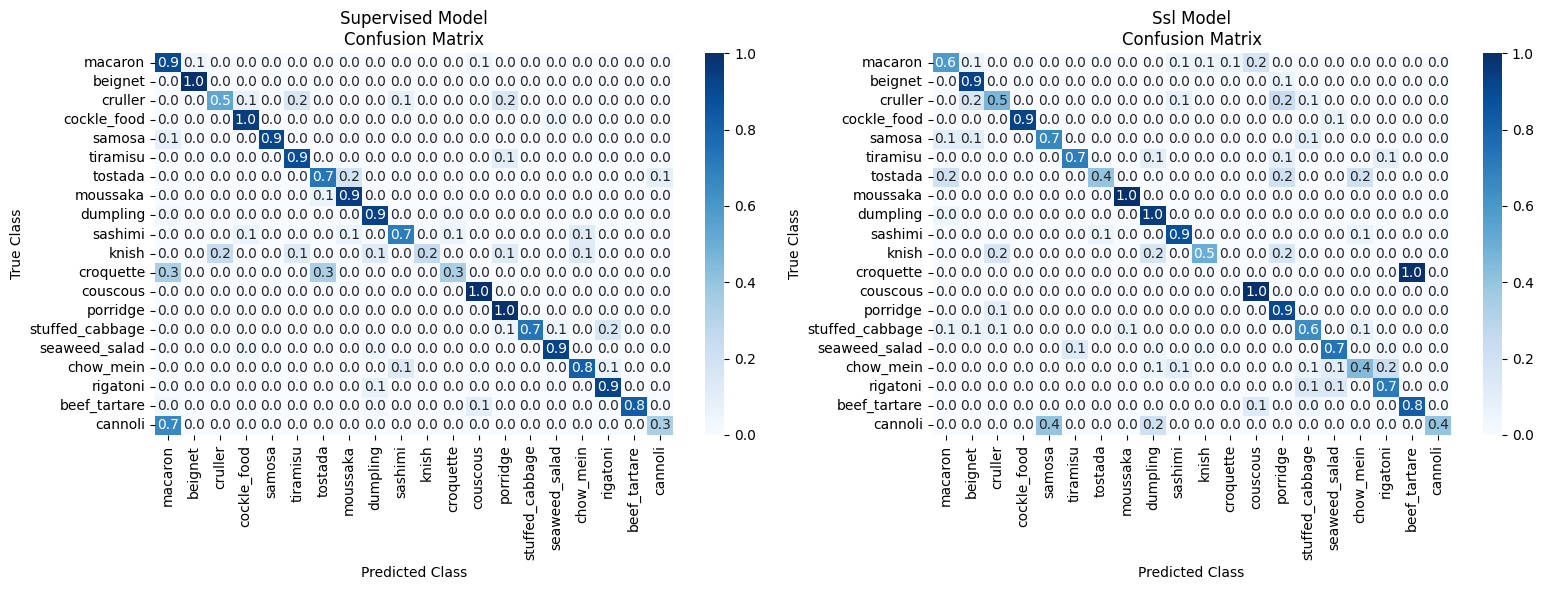


Model evaluation completed successfully!


In [9]:
class Evaluator:
  def __init__(self):
    # Initialize the parameters
    self.models = {}
    self.results = {}
    self.predictions = {}
    self.top5_metric = tf.keras.metrics.TopKCategoricalAccuracy(k=5)

  def _load_models(self):
    # Dictonary with the models with path and name
    model_files = {
        'Supervised_Model': './best_model.keras',
        'SSL_Model': './classifier_SSL.keras'
    }
    # Load the model from the dictonary
    for model_name, paths in model_files.items():
      self.models[model_name] = tf.keras.models.load_model(paths)
    return len(self.models) > 0

  def _evaluate(self, model, model_name, test_generator, class_ids):
    """
    Evaluates the model on the test_generator.
        Args: model (keras.Model): The model to evaluate.
              model_name (str): The name of the model to use for print statements.
              test_generator (ImageDataGenerator): The batches of test images and their labels.
              class_ids (list): The list with the class ids.
        Returns: results (dict): A dictionary with the results of the model.
    """
    print(f'\nEvaluating {model_name}')
    start = time.time()
    test_generator.reset()
    print(f"Test generator: {len(test_generator)} batches, {test_generator.samples} samples")

    # Instantiate predictions and ground truths to save batch for batch
    all_preds = []
    all_gt = []

    # Reset the metric state for each model evaluation
    self.top5_metric.reset_state()

    for i in range(len(test_generator)):
        try:
            # Get images and ground truths
            images, gt = test_generator[i]
            print(f"Batch {i+1}/{len(test_generator)}: {images.shape[0]} samples", end='\r')

            # Predict the batches
            batch_preds = model.predict(images, verbose=0)
            batch_gt = np.argmax(gt, axis=1)

            # Use append to maintain 2D structure
            all_preds.append(batch_preds)
            all_gt.extend(batch_gt)

            # Update the top-5 metric state
            self.top5_metric.update_state(gt, batch_preds)

        except Exception as e:
            print(f"\nError processing batch {i}: {e}")
            continue

    print()  # New line after progress

    # Check if we collected any predictions
    if not all_preds:
        print(f"No predictions collected for {model_name}")
        return None

    # Convert to numpy arrays
    try:
        predictions = np.vstack(all_preds)  # Stack 2D arrays vertically
        true_labels = np.array(all_gt)

        print(f"Collected predictions shape: {predictions.shape}")
        print(f"Collected true labels shape: {true_labels.shape}")

    except Exception as e:
        print(f"Error stacking predictions: {e}")
        print(f"Prediction shapes: {[p.shape for p in all_preds[:3]]}")  # Show first 3 shapes
        return None

    end = time.time()
    print(f'Calculated all predictions in {end-start:.2f} seconds')
    print()
    print('\nCalculating scores...')

    # Convert predictions to class labels by finding the argmax
    predicted_labels = np.argmax(predictions, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(true_labels, predicted_labels)
    top5_acc = self.top5_metric.result().numpy()

    precision = precision_score(true_labels, predicted_labels, average='weighted', zero_division=0)
    recall = recall_score(true_labels, predicted_labels, average='weighted', zero_division=0)
    f1 = f1_score(true_labels, predicted_labels, average='weighted', zero_division=0)

    precision_macro = precision_score(true_labels, predicted_labels, average='macro', zero_division=0)
    recall_macro = recall_score(true_labels, predicted_labels, average='macro', zero_division=0)
    f1_macro = f1_score(true_labels, predicted_labels, average='macro', zero_division=0)

    # Save in results
    results = {
            'accuracy': accuracy,
            'top5_accuracy': top5_acc,
            'precision_weighted': precision,
            'recall_weighted': recall,
            'f1_weighted': f1,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'f1_macro': f1_macro,
            'predictions': predictions,
            'true_labels': true_labels,
            'predictions': predictions
        }

    # Print summary
    print(f"{model_name} Scores:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Top-5 Accuracy: {top5_acc:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")
    print(f"Precision (macro): {precision_macro:.4f}")
    print(f"Recall (macro): {recall_macro:.4f}")
    print(f"F1-Score (macro): {f1_macro:.4f}")
    print(f"Evaluated on {len(true_labels)} samples")

    return results

  def compare_models(self, test_generator, class_names):
    """
    A function to compare the performances of the two models.
        Args: test_generator (ImageDataGenerator): The batches of test images and their labels.
              class_names (list): The list with the class names.
        Returns: results (dict): A dictionary with the results of the two models.
    """

    print("Starting Model Comparison")
    print("--"*50)

    # Evaluate each model
    for model_name, model in self.models.items():
        result = self._evaluate(
            model, model_name, test_generator, class_names
        )

        self.results[model_name] = result

    # Create comparison summary
    self.comparison_summary()

    return self.results

  def comparison_summary(self):
    """
    Create a summary table comparing all models
    """

    print("\nCOMPARISON SUMMARY")
    print("--"*50)

    # Create comparison DataFrame
    comparison_data = []
    # Add to the comparison data the results
    for model_name, results in self.results.items():
        comparison_data.append({
            'Model': model_name.replace('_', ' ').title(),
            'Accuracy': f"{results['accuracy']:.4f}",
            'Top-5 Acc': f"{results['top5_accuracy']:.4f}",
            'Weighted F1-Score': f"{results['f1_weighted']:.4f}",
            'Weighted Recall': f"{results['recall_weighted']:.4f}",
            'Weighted Precision': f"{results['precision_weighted']:.4f}",
            'Macro F1-Score': f"{results['f1_macro']:.4f}",
            'Macro Recall': f"{results['recall_macro']:.4f}",
            'Macro Precision':f"{results['precision_macro']:.4f}",
        })

    # Transform into a dataframe
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

    # Find best performing model
    best_model = max(self.results.keys(),
                    key=lambda x: self.results[x]['accuracy'])
    best_acc = self.results[best_model]['accuracy']

    print(f"\n Best Model (based on accuracy): {best_model.replace('_', ' ').title()}")
    print(f"   Best Accuracy: {best_acc:.4f}")


  def plot_confusion_matrices(self, class_names, max_classes=20):
    """
    Plot confusion matrices for each model.

    Args:
        class_names: List of all class names
        max_classes: Maximum number of classes to show in confusion matrix
    """
    if not self.results:
        return

    # Select subset of classes for visualization
    if len(class_names) > max_classes:
        print(f"Showing confusion matrix for top {max_classes} classes")
        selected_classes = list(range(max_classes))
    else:
        selected_classes = list(range(len(class_names)))

    n_models = len(self.results.keys())
    fig, axes = plt.subplots(1, n_models, figsize=(8*n_models, 6))

    plot_idx = 0
    for model_name, results in self.results.items():
        # Filter predictions and labels for selected classes
        mask = np.isin(results['true_labels'], selected_classes)
        true_subset = results['true_labels'][mask]
        # Apply argmax to predictions subset as well
        pred_subset = np.argmax(results['predictions'][mask], axis=1)

        # Create confusion matrix
        cm = confusion_matrix(true_subset, pred_subset, labels=selected_classes, normalize = 'true')

        # Plot
        sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues',
                    xticklabels=[class_names[i] for i in selected_classes],
                    yticklabels=[class_names[i] for i in selected_classes],
                    ax=axes[plot_idx])

        axes[plot_idx].set_title(f'{model_name.replace("_", " ").title()}\nConfusion Matrix')
        axes[plot_idx].set_xlabel('Predicted Class')
        axes[plot_idx].set_ylabel('True Class')

        plot_idx += 1

    plt.tight_layout()
    plt.show()

# Initialize evaluator and run evaluation
print("Starting Model Evaluation")
print("="*50)

evaluator = Evaluator()

# Load saved models
if evaluator._load_models():
    # Check if test_generator is available
    if 'test_generator' in locals() and test_generator is not None:
        # Check if class_names is available
        if 'class_names' in locals():
            # Run comprehensive evaluation
            evaluation_results = evaluator.compare_models(test_generator, class_names)

            # Plot confusion matrices if we have results
            if evaluation_results:
                evaluator.plot_confusion_matrices(class_names)
                print("\nModel evaluation completed successfully!")
            else:
                print("\nModel evaluation failed")

        else:
            print("class_names not available - creating generic class names")
            generic_class_names = [f"Class_{i}" for i in range(251)]
            evaluation_results = evaluator.compare_models(test_generator, generic_class_names)
    else:
        print("test_generator not available - cannot perform evaluation")
        print("Please ensure the test data generator is properly created")
else:
    print("No models could be loaded - evaluation cannot proceed")
    print("Please ensure model files exist in the current directory:")